# Olympics Analysis from 1896 to 2016
### Spring 2026 Data Science Project
**Name:** Michael Brown

**Github Repository:** [Olympics Analysis](https://github.com/Michael-1898/OlympicsAnalysis_CMSC320)

### Contributions
**Michael Brown** Sole contributor. Developed the project concept, performed data curation and preprocessing on the Olympic dataset, conducted exploratory data analysis, and performed a machine learning analysis.

---

## Introduction
TBD

---

### Library Imports
*The following libraries are used throughout this tutorial

In [32]:
import pandas as pd
import numpy as np
import string
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset Curation and Preprocessing
#### Dataset Breakdown
This section walks through the process of transforming a raw dataset into a clean, structured format ready for machine learning. This involves filtering out historical noise, handling missing values, and engineering new features that better capture the relationship between an athlete's physical profile and their success.

The primary dataset for this analysis is the 120 years of Olympic history: athletes and results, which can be found on Kaggle. This dataset contains 271,116 rows and 15 columns, tracking every athlete who participated in the Olympic Games from Athens 1896 to Rio 2016.

#### Loading the Data

In [19]:
# Load the datasets
olympics_df = pd.read_csv('athlete_events.csv')
noc_regions_df = pd.read_csv('noc_regions.csv')

# Merge with regions to have country names associated with National Olympic Committees (NOC)
olympics_df = pd.merge(olympics_df, noc_regions_df, on='NOC', how='left')

# Display the first few rows
olympics_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


#### Filtering to the Modern Era
One of the most important steps in this pipeline is narrowing the scope. Large amounts of physiological data for the early years of the Olympics (1896–1950s), like height and weight is missing. Furthermore, the level of professionalization and specialized training was different than it is today. Machine learning models are only as good as the data provided to them. So to ensure our model is accurate and relevant we filter the dataset to include only the years from 1965 onward.

In [20]:
# Filter for the modern era to ensure better data quality and relevance
modern_olympics = olympics_df[olympics_df['Year'] >= 1965].copy()

# Check for missing values in our key physical attributes
print(modern_olympics[['Height', 'Weight', 'Age']].isnull().sum())
print(f"Remaining rows: {modern_olympics.shape[0]}")

Height     9477
Weight    10068
Age         838
dtype: int64
Remaining rows: 190357


#### Handling Missing Data and Medal Column
As you can seen, even with filtering to the "modern era", some athletes still have missing physioligical data. Since our dataset is still so large we will remove rows where this information is unavailable, as it won't have too large of an impact overall. We also need to transform the Medal column into a binary target variable: Won_Medal. After this, the proportion of medalists should be much smaller than the proportion of non-medlaists.

In [21]:
# Drop rows where critical physical data is missing
modern_olympics.dropna(subset=['Height', 'Weight', 'Age'], inplace=True)

# Create a binary target variable: 1 if any medal was won, 0 otherwise
modern_olympics['Won_Medal'] = modern_olympics['Medal'].notnull().astype(int)

# Verify the class balance
print(modern_olympics['Won_Medal'].value_counts(normalize=True))

Won_Medal
0    0.857328
1    0.142672
Name: proportion, dtype: float64


#### Feature Engineering: Sport Clustering
There are over 60 different sports in the dataset. But many of these sports look for similar physical characterisitics. So we can group sports with similar physical demands into "clusters." This helps the model identify broader patterns (e.g., "Combat Sports" vs. "Endurance Sports").

We also create a combined sport/sex feature since the physical requirments can vary by sex, even within a sport (such as gymnastics).

In [22]:
# Define a mapping for sport categories
sport_map = {
    'Basketball': 'Team_Ball', 'Volleyball': 'Team_Ball', 'Football': 'Team_Ball',
    'Wrestling': 'Combat', 'Judo': 'Combat', 'Boxing': 'Combat',
    'Swimming': 'Water_Power', 'Water Polo': 'Water_Power',
    'Gymnastics': 'Aesthetic_Tech', 'Diving': 'Aesthetic_Tech',
    'Athletics': 'Track_Field', 'Weightlifting': 'Power_Strength'
}

# Apply the mapping and fill others as 'Other'
modern_olympics['Sport_Category'] = modern_olympics['Sport'].map(sport_map).fillna('Other')

# Create a combined 'Sport_Sex' feature to capture sex-based physical requirements
modern_olympics['Sport_Sex'] = modern_olympics['Sport_Category'] + "_" + modern_olympics['Sex']

#### Final Data Preparation
Lastly, we drop columns that won't be used in the model (like Name, ID, or specific Games) and convert categorical variables into a format the computer can process.

In [24]:
# Selecting columns for the final analysis
features = ['Age', 'Height', 'Weight', 'Sex', 'Sport_Category']
X = modern_olympics[features]
y = modern_olympics['Won_Medal']

# Convert categorical features into dummy variables
X_final = pd.get_dummies(X, columns=['Sex', 'Sport_Category'], drop_first=True)

print(f"Final feature set shape: {X_final.shape}")

Final feature set shape: (179335, 10)


## Exploratory Data Analysis (EDA)
Before starting our machine learning analysis, we'll perform some exploratory data analysis to identify patterns and justify specific features we will use in our predictive modeling.

#### Summary Statistics
Note the class imbalance for the Won_Medal feature. We'll have to consider this when evaluating our future model as predicting "no medal" everytime would still yield a high performance

In [25]:
# Displaying basic summary statistics for physical traits
print("Summary Statistics for Modern Olympians (1960-2016):")
display(modern_olympics[['Age', 'Height', 'Weight']].describe())

# Checking the target variable distribution
medal_counts = modern_olympics['Won_Medal'].value_counts(normalize=True) * 100
print(f"\nMedal Distribution:\n{medal_counts.map('{:.2f}%'.format)}")

Summary Statistics for Modern Olympians (1960-2016):


,Age,Height,Weight
count,179335.000000,179335.000000,179335.000000
mean,25.052700,175.573257,70.774110
std,5.450449,10.714303,14.660213
min,11.000000,127.000000,25.000000
25%,21.000000,168.000000,60.000000
50%,24.000000,175.000000,70.000000
75%,28.000000,183.000000,80.000000
max,71.000000,226.000000,214.000000



Medal Distribution:
Won_Medal
0    85.73%
1    14.27%
Name: proportion, dtype: object


#### Hypothesis Test: Does Age Drive Success?
Here we use a Welch's t-test to to determine if age is a meaningful predictor of success. We specifically use a Welch's t-test because it does not assume equal variance, as there is a large imbalance between medal vs. no medal.

**Question:** Do medalists differ physically from non-medalists?

**Null Hypothesis:** There is no difference in the mean age between athletes who did and did not win a medal.

**Alternative Hypothesis:** There is a difference in the mean age between athletes who did and did not win a medal

**Signifigance Level:** 0.01

In [29]:
# Splitting the data into medalists and non-medalists
medalists = modern_olympics[modern_olympics['Won_Medal'] == 1]['Age']
non_medalists = modern_olympics[modern_olympics['Won_Medal'] == 0]['Age']

# Welch's t-test
t_stat, p_val = ttest_ind(medalists, non_medalists, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

T-statistic: 14.9513904200285
P-value: 2.1477611608787705e-50


**Interpretation:** The extremely low p-value ($2.15 \times 10^{-50}$) allows us to reject the null hypothesis with high confidence, supporting the conclusion that there is a statistically significant difference in the mean age of medalists compared to non-medalists. This result confirms that age is a statistically relevant predictor and subsequently should be a feature in our machine learning model to help distinguish successful athletes.

#### Correlation Analysis
Next, we look at how strongly each physical trait correlates with winning a medal. A correlation heatmap helps to visualize whether any single attribute (such as being exceptionally tall) is a strong sign for Olympic success.

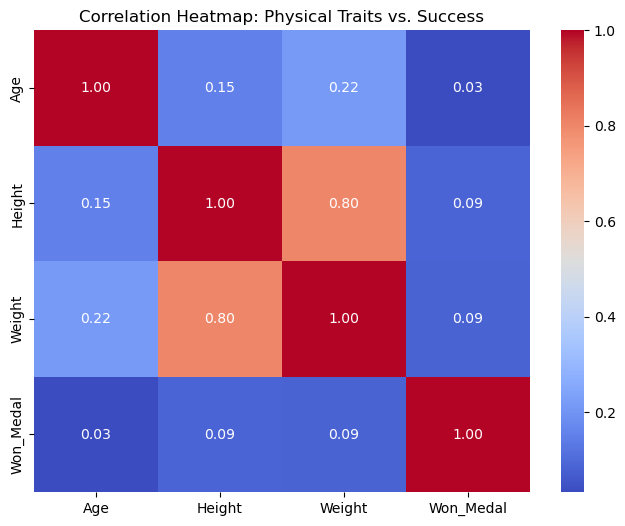

In [33]:
# Correlation matrix
corr_matrix = modern_olympics[['Age', 'Height', 'Weight', 'Won_Medal']].corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Physical Traits vs. Success')
plt.show()

**Interpretation:** The heatmap reveals very weak linear correlations between individual physical traits and winning a medal, with coefficients ranging from 0.03 for age to 0.09 for height and weight. These findings suggest that no single physical characteristic serves as a perfect predictor for Olympic success across all disciplines. Additionally, this lack of a linear signal justifies us using a more complex machine learning technique, such as a random forest, which can capture the non-linear interactions between these variables.

#### Visualization of Sport Context
The low global correlation found above occurs because the "ideal" body type changes drastically depending on the sport. To visualize this, we can look at the distribution of height across several distinct sport categories.

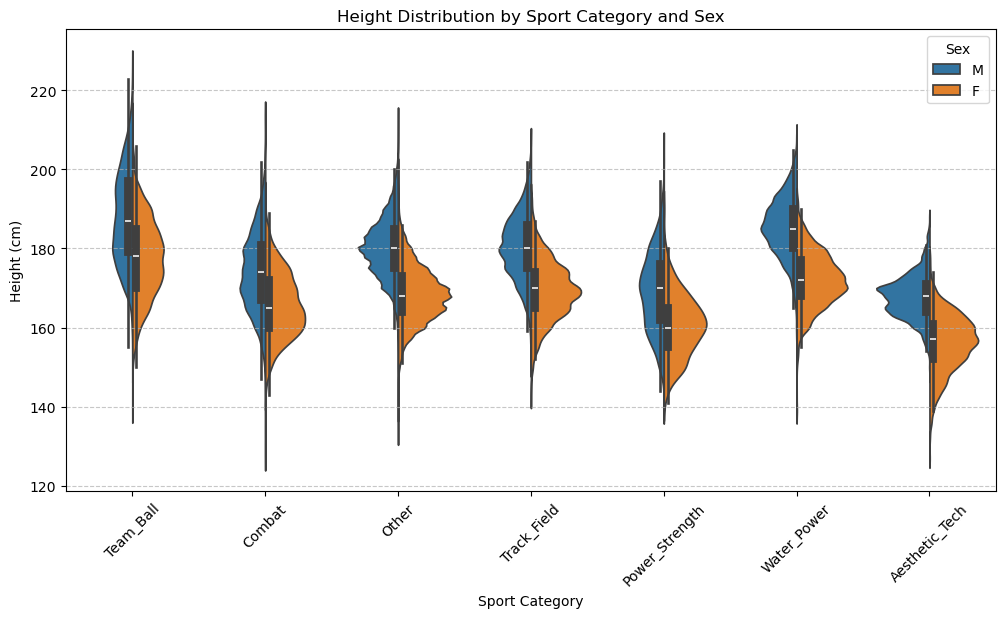

In [34]:
# Plot of height distributions by sport
plt.figure(figsize=(12, 6))
sns.violinplot(data=modern_olympics, x='Sport_Category', y='Height', hue='Sex', split=True)

plt.title('Height Distribution by Sport Category and Sex')
plt.xlabel('Sport Category')
plt.ylabel('Height (cm)')
plt.xticks(rotation=45)
plt.legend(title='Sex', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretation:** This visualization demonstrates that ideal physical archetypes are highly dependent on the specific sport. For example, athletes in Team_Ball are significantly taller on average than those in Aesthetic_Tech. The distinct, non-overlapping distributions across categories prove that physical data cannot be interpreted in a vacuum. This justifies us include Sport_Sex as a primary feature in our model, allowing the algorithm to evaluate an athlete's height and weight within the context of their specific event's requirements.

## Machine Learning Algorithm Development